In [9]:
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from Bio import Entrez
from sklearn.metrics.pairwise import cosine_similarity
import torch
from collections import Counter
import time
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIG ===
Entrez.email = ""  # REQUIRED
csv_path = "C:/Users/venka/Downloads/analysis_results.csv"
output_csv = "pubmed_edc_results.csv"
max_results_per_query = 10
request_delay = 1  # seconds between NCBI requests

# === LOAD EDCs FROM CSV ===
df = pd.read_csv(csv_path)
edc_column = df["Matched Official EDC Name"].dropna()

# Count frequency and pick top 10
edc_counts = Counter(edc_column)
top_10_edcs = [edc for edc, count in edc_counts.most_common(10)]

print(f"✅ Loaded {len(edc_column)} entries, {len(edc_counts)} unique EDCs.")
print("Top 10 most common EDCs:")
for i, (edc, count) in enumerate(edc_counts.most_common(10), 1):
    print(f"  {i}. {edc} ({count} occurrences)")

# === LOAD PUBMEDBERT MODEL ===
model_name = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# === HELPER: GET CLS EMBEDDING ===
def get_cls_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :]  # CLS token

# === HELPER: FETCH ABSTRACTS (BATCH MODE) ===
def fetch_pubmed_abstracts(query, max_results=10):
    try:
        # Search PubMed
        search_handle = Entrez.esearch(db="pubmed", term=query, retmax=max_results)
        search_results = Entrez.read(search_handle)
        search_handle.close()
        
        pmids = search_results["IdList"]
        if not pmids:
            return []
        
        # Fetch all in one request (XML mode)
        fetch_handle = Entrez.efetch(db="pubmed", id=",".join(pmids), rettype="abstract", retmode="xml")
        records = Entrez.read(fetch_handle)
        fetch_handle.close()
        
        abstracts = []
        for article in records["PubmedArticle"]:
            pmid = article["MedlineCitation"]["PMID"]
            abstract_text = ""
            if "Abstract" in article["MedlineCitation"]["Article"]:
                for part in article["MedlineCitation"]["Article"]["Abstract"]["AbstractText"]:
                    abstract_text += str(part) + " "
            if abstract_text.strip():
                abstracts.append((pmid, abstract_text.strip()))
        
        return abstracts
    except Exception as e:
        print(f"Error fetching abstracts: {e}")
        return []

# === PROMPT EMBEDDING ===
danger_prompt = "This chemical causes cancer, infertility, or endocrine disruption."
prompt_emb = get_cls_embedding(danger_prompt)

# === RUN ANALYSIS ===
results = []
scores_by_edc = {}  # For box plot data

for i, edc in enumerate(top_10_edcs, 1):
    print(f"\n🔬 Analyzing #{i}: {edc} ({edc_counts[edc]} occurrences)")
    
    query = f"{edc} AND (toxicity OR endocrine disruption OR carcinogen OR reproductive)"
    abstracts = fetch_pubmed_abstracts(query, max_results=max_results_per_query)
    
    if not abstracts:
        print("❌ No abstracts found.")
        scores_by_edc[edc] = []  # Empty list for EDCs with no results
        continue
    
    ranked = []
    edc_scores = []  # Store scores for this EDC
    
    for pmid, abs_text in abstracts:
        abs_emb = get_cls_embedding(abs_text)
        score = cosine_similarity(prompt_emb, abs_emb)[0][0]
        ranked.append((score, pmid, abs_text))
        edc_scores.append(score)
    
    # Store scores for box plot
    scores_by_edc[edc] = edc_scores
    
    ranked.sort(reverse=True, key=lambda x: x[0])
    
    # Keep top 3 for display
    for score, pmid, abs_text in ranked[:3]:
        print(f"\n🧾 PMID: {pmid} | Score: {score:.3f}")
        print(abs_text[:300] + "..." if len(abs_text) > 300 else abs_text)
        print("-" * 80)
        
        results.append({
            "EDC": edc,
            "PMID": pmid,
            "Cosine_Score": score,
            "Abstract": abs_text
        })
    
    time.sleep(request_delay)  # be polite to NCBI

# === SAVE RESULTS ===
results_df = pd.DataFrame(results)
results_df.to_csv(output_csv, index=False)
print(f"\n🎉 Analysis complete! Results saved to {output_csv}")

✅ Loaded 127 entries, 37 unique EDCs.
Top 10 most common EDCs:
  1. alpha-tocopherol (19 occurrences)
  2. aluminum (8 occurrences)
  3. ethylene oxide (8 occurrences)
  4. iron (7 occurrences)
  5. 4-hydroxyacetophenone (6 occurrences)
  6. styrene (6 occurrences)
  7. titanium dioxide nanoparticles (5 occurrences)
  8. caffeine (5 occurrences)
  9. caprylic acid (5 occurrences)
  10. propylene glycol (5 occurrences)

🔬 Analyzing #1: alpha-tocopherol (19 occurrences)

🧾 PMID: 40605208 | Score: 0.650
To assess the preventive role of alpha-tocopherol (vitamin E) and alpha-lipoic acid (ALA) in isoniazid-induced hepatitis. Experimental study. Place and Duration of the Study: Department of Pharmacology, Army Medical College, National University of Medical Sciences, Rawalpindi, and National Institute...
--------------------------------------------------------------------------------

🧾 PMID: 40779026 | Score: 0.582
Propanil is the most widely used herbicide in the world, which posing a grea

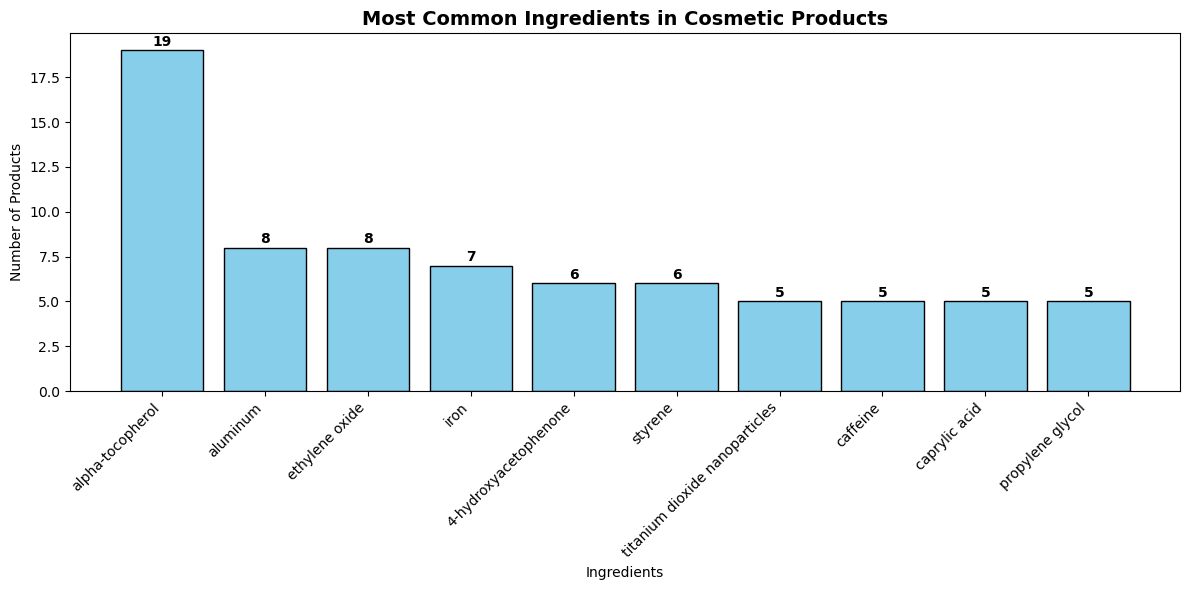

TOP 10 MOST COMMON INGREDIENTS
 1. alpha-tocopherol          | 19 products
 2. aluminum                  |  8 products
 3. ethylene oxide            |  8 products
 4. iron                      |  7 products
 5. 4-hydroxyacetophenone     |  6 products
 6. styrene                   |  6 products
 7. titanium dioxide nanoparticles |  5 products
 8. caffeine                  |  5 products
 9. caprylic acid             |  5 products
10. propylene glycol          |  5 products


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load your data
csv_path = "C:/Users/venka/Downloads/analysis_results.csv"  # Update this path if needed

try:
    # Load CSV file
    df = pd.read_csv(csv_path, header=None)
    edc_column = df.iloc[:, 2].dropna()
except:
    df = pd.read_csv(csv_path, header=0)
    edc_column = df.iloc[:, 2].dropna()

# Count ingredients
edc_counts = Counter(edc_column)
top_10_edcs = edc_counts.most_common(10)

# Extract data for plotting
ingredients = [item[0] for item in top_10_edcs]
frequencies = [item[1] for item in top_10_edcs]

# Create simple bar chart
plt.figure(figsize=(12, 6))
plt.bar(ingredients, frequencies, color='skyblue', edgecolor='black')

# Customize chart
plt.title('Most Common Ingredients in Cosmetic Products', fontsize=14, fontweight='bold')
plt.xlabel('Ingredients')
plt.ylabel('Number of Products')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for i, v in enumerate(frequencies):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom', fontweight='bold')

# Show the plot
plt.tight_layout()
plt.show()

# Print summary
print("=" * 50)
print("TOP 10 MOST COMMON INGREDIENTS")
print("=" * 50)
for i, (ingredient, count) in enumerate(top_10_edcs, 1):
    print(f"{i:2d}. {ingredient:<25} | {count:2d} products") 

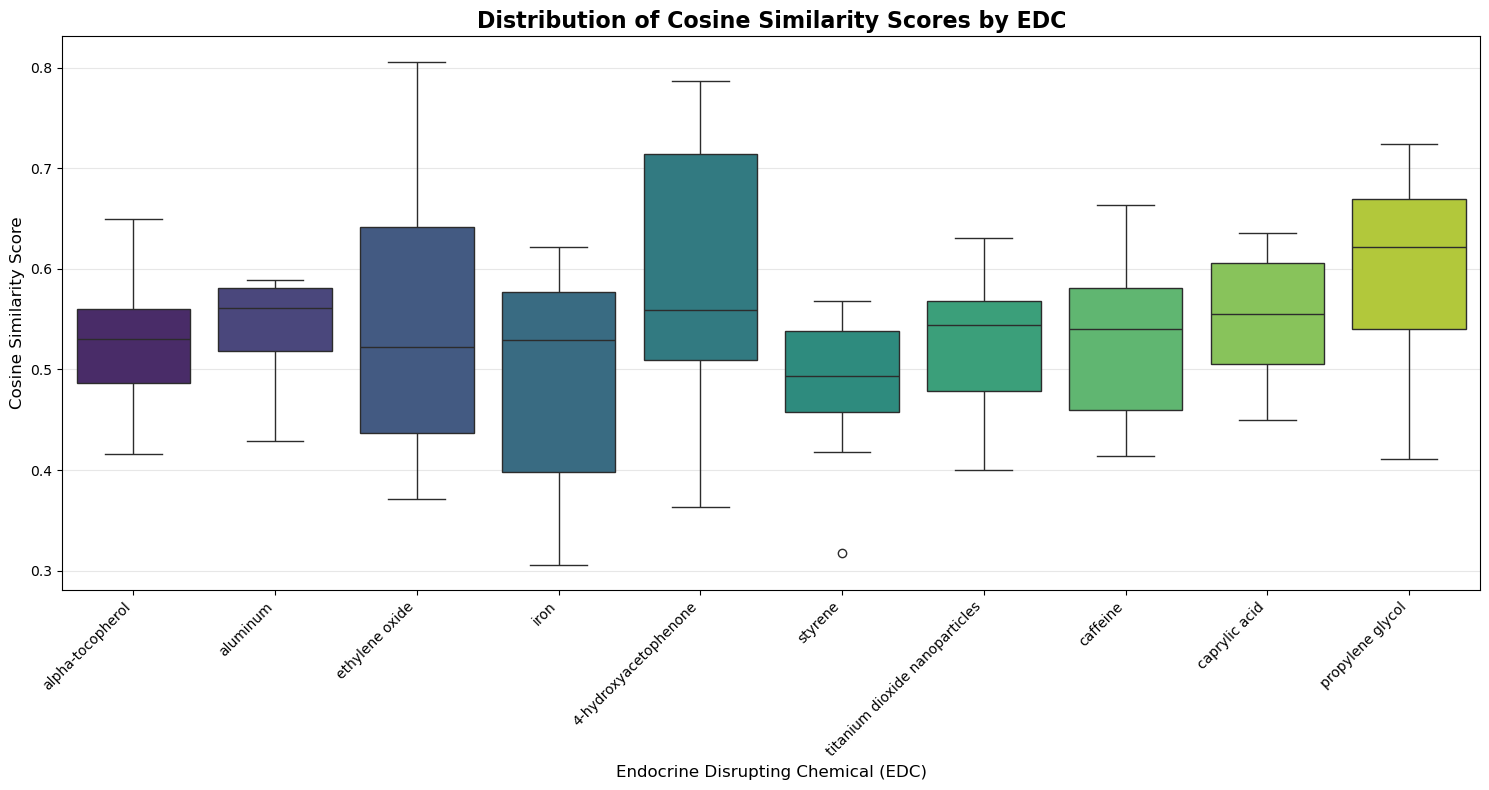


📊 Summary Statistics:
                                count   mean    std    min    max
EDC                                                              
4-hydroxyacetophenone              10  0.579  0.148  0.363  0.787
alpha-tocopherol                   10  0.526  0.066  0.416  0.650
aluminum                           10  0.542  0.051  0.429  0.589
caffeine                           10  0.530  0.084  0.414  0.663
caprylic acid                      10  0.553  0.063  0.450  0.636
ethylene oxide                     10  0.544  0.146  0.372  0.806
iron                               10  0.493  0.110  0.306  0.622
propylene glycol                   10  0.604  0.101  0.411  0.725
styrene                            10  0.485  0.076  0.318  0.568
titanium dioxide nanoparticles     10  0.525  0.068  0.400  0.630


In [10]:
# === CREATE BOX PLOT ===
# Prepare data for plotting
plot_data = []
for edc, scores in scores_by_edc.items():
    for score in scores:
        plot_data.append({"EDC": edc, "Cosine_Score": score})

plot_df = pd.DataFrame(plot_data)

if not plot_df.empty:
    # Create box plot
    plt.figure(figsize=(15, 8))
    
    # Use seaborn for better styling
    sns.boxplot(data=plot_df, x="EDC", y="Cosine_Score", palette="viridis")
    
    plt.title("Distribution of Cosine Similarity Scores by EDC", fontsize=16, fontweight='bold')
    plt.xlabel("Endocrine Disrupting Chemical (EDC)", fontsize=12)
    plt.ylabel("Cosine Similarity Score", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    
    plt.show()
    
    # Print summary statistics
    print("\n📊 Summary Statistics:")
    summary_stats = plot_df.groupby("EDC")["Cosine_Score"].agg(['count', 'mean', 'std', 'min', 'max']).round(3)
    print(summary_stats)
    
else:
    print("❌ No data available for plotting.")